In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("ticks")

In [2]:
# === PLOT CONFIGURATION ===

mm = 1 / 25.4     # conversion from millimeters to inches
cm = 1 / 2.54     # conversion from centimeters to inches
pt = 1 / 72.27    # conversion from points to inches

# The values below are obtained from LaTeX, using \the\columnwidth and \the\textwidth
PAPER_COLUMN = 347.12361  # points
PAPER_TEXTWIDTH = 347.12361*2  # points

RESOLUTION = 150  # 'DPI', but actually PPI

# Color palette for heatmap
CMAP = 'viridis'

# Font settings
LABEL_FONTSIZE = 9
TICK_FONTSIZE = 8
ANNOT_FONTSIZE = 7
TITLE_FONTSIZE = 10

# Annotation settings
SHOW_VALUES = True
VALUE_FORMAT = '.2f'

In [4]:
RESULTS_ROOT = Path("../results/anomaly_detection")

# Methods (columns) and datasets (rows)
METHODS = ["nf", "mean_sigmoid", "min_sigmoid"]
METHOD_LABELS = {"nf": "NF", "mean_sigmoid": "mean-$\sigma$", "min_sigmoid": "min-$\sigma$"}

DATASETS = ["actions", "activity", "verbs"]
DATASET_LABELS = {"actions": "HumanAct12", "activity": "ESK Activities", "verbs": "ESK Verbs"}

# Map (method, dataset) -> folder name
EXPERIMENT_FOLDERS = {
    ("nf", "actions"):           "nf_actions_20260310_192939",
    ("nf", "activity"):          "nf_actions_20260310_192939",
    ("nf", "verbs"):             "nf_verbs_20260310_180632",
    ("mean_sigmoid", "actions"):  "mean_sigmoid_actions_20260310_193046",
    ("mean_sigmoid", "activity"): "mean_sigmoid_activity_20260310_192821",
    ("mean_sigmoid", "verbs"):    "mean_sigmoid_verbs_20260310_183640",
    ("min_sigmoid", "actions"):   "min_sigmoid_actions_20260310_193105",
    ("min_sigmoid", "activity"):  "min_sigmoid_activity_20260310_192858",
    ("min_sigmoid", "verbs"):     "min_sigmoid_verbs_20260310_184237",
}


def load_experiment(folder: str) -> dict:
    """Load a results.json produced by anomaly detection."""
    path = RESULTS_ROOT / folder / "results.json"
    with open(path) as f:
        raw = json.load(f)

    activities = raw["activity_names"]
    n = len(activities)

    def _to_float(v):
        if v is None:
            return np.nan
        fv = float(v)
        return np.nan if fv != fv else fv

    auc_matrix = np.array(
        [[_to_float(v) for v in row] for row in raw["auc_matrix"]],
        dtype=float,
    )

    return {
        "activities": activities,
        "auc_matrix": auc_matrix,
        "mean_auc": raw.get("mean_auc", np.nan),
        "method": raw["method"],
        "label_type": raw["label_type"],
    }


# Load all 9 experiments into a nested dict: experiments[dataset][method]
experiments = {}
for dataset in DATASETS:
    experiments[dataset] = {}
    for method in METHODS:
        folder = EXPERIMENT_FOLDERS[(method, dataset)]
        experiments[dataset][method] = load_experiment(folder)
        d = experiments[dataset][method]
        print(f"{DATASET_LABELS[dataset]} / {METHOD_LABELS[method]}: "
              f"mean AUC = {d['mean_auc']:.4f}, "
              f"activities = {d['activities']}")

HumanAct12 / NF: mean AUC = 0.5731, activities = ['drink', 'jump', 'run', 'throw', 'walk']
HumanAct12 / mean-$\sigma$: mean AUC = 0.5252, activities = ['drink', 'jump', 'run', 'throw', 'walk']
HumanAct12 / min-$\sigma$: mean AUC = 0.5304, activities = ['drink', 'jump', 'run', 'throw', 'walk']
ESK Activities / NF: mean AUC = 0.5731, activities = ['drink', 'jump', 'run', 'throw', 'walk']
ESK Activities / mean-$\sigma$: mean AUC = 0.5330, activities = ['experimental procedure', 'getting ready', 'cleaning', 'cooking', 'preparing ingredients']
ESK Activities / min-$\sigma$: mean AUC = 0.5279, activities = ['experimental procedure', 'getting ready', 'cleaning', 'cooking', 'preparing ingredients']
ESK Verbs / NF: mean AUC = 0.5682, activities = ['Add', 'Cut', 'Move', 'Stir', 'Carry']
ESK Verbs / mean-$\sigma$: mean AUC = 0.5177, activities = ['Add', 'Cut', 'Move', 'Stir', 'Carry']
ESK Verbs / min-$\sigma$: mean AUC = 0.5155, activities = ['Add', 'Cut', 'Move', 'Stir', 'Carry']


/tmp/ipykernel_335820/1604868269.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to: anomaly_grid.pdf


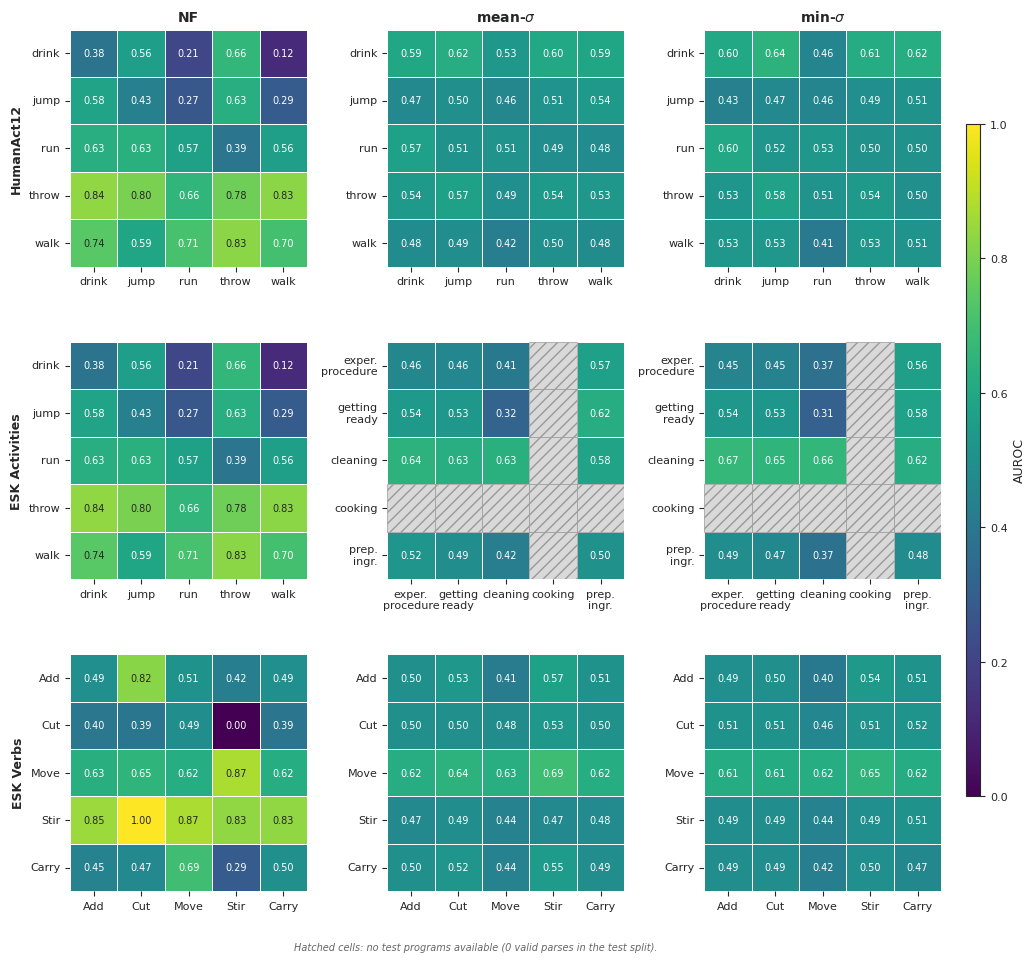

In [5]:
def plot_auc_grid(
    experiments: dict,
    datasets: list[str],
    methods: list[str],
    dataset_labels: dict,
    method_labels: dict,
    cmap: str = CMAP,
    show_values: bool = SHOW_VALUES,
    save_path: str = None,
):
    """
    Plot pairwise AUROC separability matrices in a grid.
    Rows = datasets, Columns = methods.
    NaN cells (e.g. cooking with no test programs) are hatched.
    """
    n_rows = len(datasets)
    n_cols = len(methods)

    # Compute per-subplot size so each heatmap is roughly square
    cell_w = PAPER_TEXTWIDTH * pt / n_cols
    cell_h = cell_w  # keep square-ish
    fig_w = PAPER_TEXTWIDTH * pt
    fig_h = cell_h * n_rows

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(fig_w, fig_h),
        squeeze=False,
    )

    has_missing = False

    for row_idx, dataset in enumerate(datasets):
        for col_idx, method in enumerate(methods):
            ax = axes[row_idx, col_idx]
            d = experiments[dataset][method]
            auc_matrix = d["auc_matrix"]
            activities = d["activities"]

            wrapped = [a.replace(" ", "\n").replace("_", "\n") for a in activities]
            # Abbreviate long labels
            wrapped = [a.replace("experimental", "exper.") for a in wrapped]
            wrapped = [a.replace("preparing", "prep.") for a in wrapped]
            wrapped = [a.replace("ingredients", "ingr.") for a in wrapped]

            mask = np.isnan(auc_matrix)
            if mask.any():
                has_missing = True

            sns.heatmap(
                auc_matrix,
                annot=auc_matrix if show_values else False,
                fmt=VALUE_FORMAT if show_values else "",
                cmap=cmap,
                vmin=0.0,
                vmax=1.0,
                mask=mask,
                square=True,
                linewidths=0.5,
                linecolor="white",
                cbar=False,
                annot_kws={"size": ANNOT_FONTSIZE},
                ax=ax,
            )

            # Hatch NaN cells so they're clearly marked as missing
            n = len(activities)
            for i in range(n):
                for j in range(n):
                    if mask[i, j]:
                        ax.add_patch(plt.Rectangle(
                            (j, i), 1, 1,
                            fill=True, facecolor="#d9d9d9",
                            hatch="///", edgecolor="#999999", linewidth=0.5,
                        ))

            ax.set_xticklabels(wrapped, rotation=0, fontsize=TICK_FONTSIZE)
            ax.set_yticklabels(wrapped, rotation=0, fontsize=TICK_FONTSIZE)

            # Row labels on leftmost column
            if col_idx == 0:
                ax.set_ylabel(dataset_labels[dataset],
                              fontsize=LABEL_FONTSIZE, fontweight="bold")
            else:
                ax.set_ylabel("")

            # Column titles on top row
            if row_idx == 0:
                ax.set_title(f"{method_labels[method]}",
                             fontsize=TITLE_FONTSIZE, fontweight="bold", pad=6)

    # Add shared colorbar
    cbar_ax = fig.add_axes([1.01, 0.15, 0.015, 0.7])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("AUROC", fontsize=LABEL_FONTSIZE)
    cbar.ax.tick_params(labelsize=TICK_FONTSIZE)

    plt.tight_layout()

    # Footnote if any cells were missing
    if has_missing:
        fig.text(
            0.5, -0.01,
            "Hatched cells: no test programs available (0 valid parses in the test split).",
            ha="center", fontsize=TICK_FONTSIZE - 1, style="italic", color="#666666",
        )

    if save_path:
        plt.savefig(save_path, dpi=RESOLUTION, bbox_inches="tight", facecolor="white")
        print(f"Saved to: {save_path}")

    plt.show()
    return fig


fig = plot_auc_grid(
    experiments, DATASETS, METHODS,
    DATASET_LABELS, METHOD_LABELS,
    save_path="anomaly_grid.pdf",
)